# Problem Set 5: Trees, Forests, and Fairness in ML


Your mission for this problem set is to use your knowledge of tree-based methods and supervised learning to -- among other things! -- explore issues of fairness in machine learning (ML). Unlike in previous psets, where we were implementing algorithms from scratch, this pset will rely more heavily on sklearn. Unless explicitly noted otherwise, you are allowed (encouraged!) to make good use of this wonderful library. 

This problem set will also rely on the resources provided by the [folktables](https://github.com/socialfoundations/folktables?tab=readme-ov-file) project. Before getting started, take some time to understand what folktables is about and how it can be used to benchmark ML algorithms in social science. If you don't understand the basics, this pset will be very challenging!!

Some resources you might find useful:

[Folktables paper](https://arxiv.org/abs/2108.04884)

[Folktables video](youtube.com/watch?v=KP7DhM_ahHI)

[PUMS_Data_Dictionary_2018](https://www2.census.gov/programssurveys/acs/tech_docs/pums/data_dict/PUMS_Data_Dictionary_2018.pdf)

[Fairness in ML](https://fairmlbook.org/classification.html)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folktables
import seaborn as sns

## Part I: Setup of prediction task

### 1.1 Define the income prediction task

For this first question we are providing the code. Run it to download the data you'll be using throughout this problem set. 

Begin by explaining what this prediction task is about and what is this code accomplishing:

* Where do the data come from
* What is the sample?
* What are we trying to predict?
* What are the features that we will be using?
* What is the "group" feature about?


In [2]:
from folktables import ACSDataSource, generate_categories

def adult_filter(data):
    """Mimic the filters in place for Adult data.

    Adult documentation notes: Extraction was done by Barry Becker from
    the 1994 Census database. A set of reasonably clean records was extracted
    using the following conditions:
    ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))
    """
    df = data
    df = df[df['AGEP'] > 16]
    df = df[df['PINCP'] > 100]
    df = df[df['WKHP'] > 0]
    df = df[df['PWGTP'] >= 1]
    return df

ACSIncome = folktables.BasicProblem(
    features=[
        'AGEP',
        'COW',
        'SCHL',
        'MAR',
        'POBP',
        'RELP',
        'WKHP',
        'SEX',
        'RAC1P',
    ],
    target='PINCP',
    target_transform = lambda x: x > 50000,
    group='RAC1P',
    preprocess=adult_filter,
    postprocess=lambda x: np.nan_to_num(x, -1),
)

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["CA"], download=True)
definition_df = data_source.get_definitions(download=True)
categories = generate_categories(features=ACSIncome.features, definition_df=definition_df)
features, target, group = ACSIncome.df_to_pandas(acs_data)

feature_names = ACSIncome.features
target_name = ACSIncome.target
group_name = ACSIncome.group

* Where do the data come from?
    - This data comes from Folktables, a python package that provides access to US census datasets. The data source used in this function comes from 2018  american community survey specifically for the state of California. 
* What is the sample?
    - The data sample used in this function comes from 2018 american community survey specifically for the state of California. The adult_filter function, is filtering the data for Age > 16, Income > 100, Hours worked per week >0 and a person weighting variable >= 1. 
* What are we trying to predict?
    - The target vairable here is 'PINCP' which is total person's income.  
* What are the features that we will be using?
    - The features we are using are:
        - 'AGEP' = Age
        - 'COW' =  Class of worker
        - 'SCHL' = Educational attainment 
        - 'MAR' = Marital status
        - 'POBP' = Place of birth
        - 'RELP' = relationship 
        - 'WKHP' =  Hours worked per week (past year)
        - 'SEX' =  sex 
        - 'RAC1P' = race
* What is the "group" feature about? 
    - The group feature allows for groupings of the data based on a specific feature, like 'RAC1P': that could allow for the evaluation of a given model's violation of equality of opportunity.

### 1.2 Split into train and test

Split your data into 80%-20% train and test splits. Please use sklearn.model_selection.train_test_split and set the random_state parameter equal to 0.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    features, target, group, test_size=0.2, random_state=0)

### 1.3 Explore the data and set appropriate data types

Create 2-3 figures and tables that explore the training data, and tell us what insights you can draw from those figures. Which features are best represented as numerical data types? Which features are best represented as categorical data types? Set each feature to its desired data type in both train and test splits. Make sure that the target variable in both splits is numeric before moving ahead.

In [4]:
# Set numerical variables

X_train['WKHP'] = X_train['WKHP'].astype('float64')
X_train['AGEP'] = X_train['AGEP'].astype('float64')

X_test['WKHP'] = X_test['WKHP'].astype('float64')
X_test['AGEP'] = X_test['AGEP'].astype('float64')

# Set categorical variables 
X_train['COW'] = X_train['COW'].astype('int').astype('category')
X_train['SCHL'] = X_train['SCHL'].astype('int').astype('category')
X_train['MAR'] = X_train['MAR'].astype('int').astype('category')
X_train['POBP'] = X_train['POBP'].astype('int').astype('category')
X_train['SEX'] = X_train['SEX'].astype('int').astype('category')
X_train['RAC1P'] = X_train['RAC1P'].astype('int').astype('category')


X_test['COW'] = X_test['COW'].astype('int').astype('category')
X_test['SCHL'] = X_test['SCHL'].astype('int').astype('category')
X_test['MAR'] = X_test['MAR'].astype('int').astype('category')
X_test['POBP'] = X_test['POBP'].astype('int').astype('category')
X_test['SEX'] = X_test['SEX'].astype('int').astype('category')
X_test['RAC1P'] = X_test['RAC1P'].astype('int').astype('category')

# Convert target true and false to binary 
y_train['PINCP'] = y_train['PINCP'].astype('int')
y_test['PINCP'] = y_test['PINCP'].astype('int')


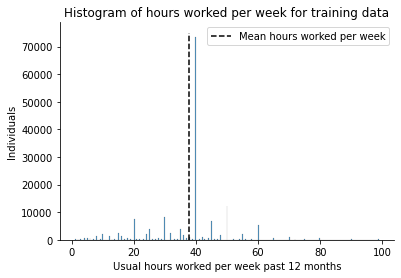

In [5]:
# Figure 1: Hours worked per week 
sns.histplot(X_train['WKHP'])
plt.vlines( X_train['WKHP'].mean(),0,75000, linestyle = 'dashed', color = 'black', label = 'Mean hours worked per week')
plt.xlabel('Usual hours worked per week past 12 months')
plt.ylabel('Individuals')
plt.title('Histogram of hours worked per week for training data')
plt.legend()
sns.despine()

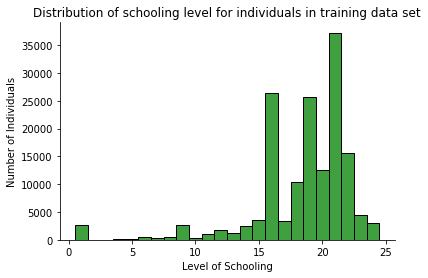

In [6]:
# Figure 2: 
sns.histplot(X_train['SCHL'],  color = 'green')
plt.xlabel('Level of Schooling')
plt.ylabel('Number of Individuals')
plt.title('Distribution of schooling level for individuals in training data set')
sns.despine()

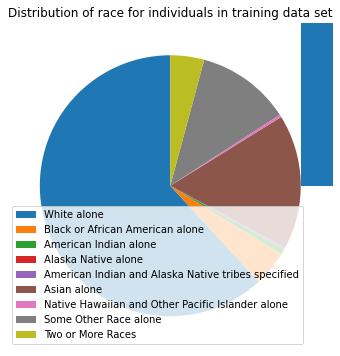

In [7]:
# Figure 3: Race distribution pie chart for training data
plt.figure(figsize=(6,6))
race_dist = plt.hist(X_train['RAC1P'], bins = 9)
labels_RAC1P = ['White alone',
 'Black or African American alone',
 'American Indian alone',
 'Alaska Native alone',
 'American Indian and Alaska Native tribes specified',
 'Asian alone',
 'Native Hawaiian and Other Pacific Islander alone',
 'Some Other Race alone',
 'Two or More Races']
# plt.pie(race_dist[0], labels=labels_RAC1P, autopct='%1.1f%%')
patches, texts = plt.pie(race_dist[0], startangle=90)
plt.legend(patches, labels_RAC1P, loc="lower left")
plt.title('Distribution of race for individuals in training data set')
plt.show()



1. Which features are best represented as numerical data types?
- age (AGEP) and usual hours worked per week (WKHP)
2. Which features are best represented as categorical data types?
- class of worker (COW), marital status (MAR), sex (SEX), racial code (RAC1P), place of birth (POBP), educational attainment (SCHL)

## Part II: ML pipeline for a Classification Tree

Next, you'll build an ML pipeline using sklearn. Take some time to familiarize yourself with [sklearn.pipeline.Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) before proceeding.

### 2.1 Pre-processing of features

The first step of the pipeline will standardize the numeric features and one-hot encode the categorical features. Write the code for this preprocessing step below. 

**Hint**: Take a look at sklearn's ColumnTransformer, OneHotEncoder and StandardScaler for this task. 

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define numeric features and transform them using standard scaler
numeric_features = ['WKHP', 'AGEP']
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

# Define categorical features and encode them using one hot encoder 
categorical_features = ['COW', 'SCHL', 'MAR', 'POBP', 'RELP', 'SEX', 'RAC1P']
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown='ignore'))]
)

# Define pre-processor for later on
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### 2.2 Use your pre-processed data to fit a basic DecisionTreeClassifier

Now, bring together the pre-processing step with a Decision Tree Classifier in a pipeline. For now, use the default values; we'll take care of hyperparameter optimization later. Fit the pipeline on the training data. How deep is the resulting tree? How many leafs are in the tree? Print the 10 variables with highest feature importance and tell us what those importances mean in plain English. Plot the top 5 levels of the fitted decision tree. Make sure that the nodes are appropriately labeled. Comment on anything that you find interesting.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# # Fit model using pipline 
clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=0))])
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['WKHP', 'AGEP']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['COW', 'SCHL', 'MAR', 'POBP',
                                                   'RELP', 'SEX', 'RAC1P'])])),
                ('classifier', DecisionTreeClassifier(random_state=0))])

In [16]:
# 1. Determine the depth of the tree
tree_depth = clf['classifier'].get_depth()
print("Depth of the tree:", tree_depth)

# 2. Count the number of leafs in the tree
leaf_count = clf['classifier'].get_n_leaves()
print("Number of leaf nodes:", leaf_count)

# 3. 10 variables with highest feature importance
# Get feature importances
feature_importance = clf['classifier'].feature_importances_
top_features = np.argsort(feature_importance)[::-1][:10]

# Get names of transformed features
new_feature_names = preprocessor.get_feature_names_out()

# print("Top 10 variables with highest feature importance:")
# for idx in top_features:
#     print(f"{new_feature_names[idx]}: {feature_importance[idx]}")

# # 4. Plot the top 5 levels of the fitted decision tree
# fig = plt.figure(figsize=(25,20))
# tree.plot_tree(clf['classifier'], max_depth=5,feature_names = new_feature_names, class_names=['True', 'False'], filled=True, fontsize=10)
# plt.show()

Depth of the tree: 88
Number of leaf nodes: 37889


_ANSWERS_
1. The variables with the highest feature importance are:
    - num__AGEP: 0.2336718081551264
    - num__WKHP: 0.20110720194768678
    - cat__POBP_303: 0.04856997464276286
    - cat__SCHL_21: 0.031870444669552245
    - cat__SCHL_22: 0.027116010059415465
    - cat__SCHL_16: 0.024497287736344332
    - cat__SCHL_23: 0.018335039577390334
    - cat__POBP_6: 0.016713378724138934
    - cat__COW_1: 0.015924649877269135
    - cat__RELP_0.0: 0.01590516959562802
2. Feature improtance represents the relative importance of each sub-feature in making predictions in the decision tree. The feature importance is calculated as how much each feature reduces the Gini impurity in the _tree node_.  Higher importance indicates that sub-feature has a greater effect on reduction of impurtiy and hence a stronger influence on the tree's decision.

### 2.3 Estimate AUC using K-Fold CV

Calculate the 5-fold cross-validated AUC-ROC for this simple tree pipeline. Report the score for each fold as well as the average across all folds. 

**Hint 1**: sklearn.model_selection.cross_val_score is your friend. Setting the verbose option to 3 is useful. 

In [9]:
from sklearn.model_selection import cross_val_score

# Calculate cross-validated AUC-ROC scores
tree_clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=0))])
# auc_roc_scores = cross_val_score(tree_clf, X_train, y_train, cv=5, scoring='roc_auc', verbose = 3)

# # Calculate the mean AUC-ROC score
# mean_auc_roc_score = auc_roc_scores.mean()

In [12]:
# Report scores
print('AUC-ROC score for each fold:'+ str(auc_roc_scores))
print('Mean 5-fol CV AUC-ROC: '+ str(mean_auc_roc_score))

AUC-ROC score for each fold:[0.73634837 0.73854879 0.73581141 0.73735245 0.73675995]
Mean 5-fol CV AUC-ROC: 0.7369641943576709


### 2.4 Estimating AUC using nested CV 

Let's try to improve on the results of the decision tree by tweaking its hyperparameters. Since you already are an expert using nested CV, this is going to be a walk in the park! Compute the nested cv AUC-ROC of a decision tree pipeline. Use 5 folds for the inner loop and 3 folds for the outer loop. Include different values for "max_depth", "max_features" and "max_leave_nodes" in your hyperparameter grid. Report the inner and outer fold scores for all combinations of hyperparams and interpret the results. Report the best hyperparameters used in each outer fold. How stable are the results?

What else do you notice in these results? To what extent do you think specific hyperparameters might lead to overfitting? How is run-time impacted by your choice of hyperparameters? Is hyperparameter optimization worth the trouble?

**Hint 1**: The pipeline remains the same. You can access the list of| all the hyperparams in your pipeline with pipeline.get_params_keys(). Notice the naming convention.

**Hint 2**: GridSearchCV and cross_val_score are your friends-- especially if you run them with verbose = 3.

**Hint 3**: This gets computationally expensive quickly. Be intelligent about the hyperparameter values you include in the grid and the number of outer and inner folds you use (we use 5 inner folds and 3 outer folds).

In [10]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import roc_auc_score


# # Define hyperparameter grid
# tot_n_features = len(new_feature_names)
# param_grid = {
#     'classifier__max_depth': [25, 50, 75],
#     'classifier__max_features': [tot_n_features, 'sqrt', 'log2'],
#     'classifier__max_leaf_nodes': [1000, 1500, 2000]
# }

# # Initialize inner/outer cross-validation folds 
# outer_cv_folds = 3
# inner_cv_folds = 5

# # Initialize lists to store results
# outer_scores = []
# best_params_list = []

# # Perform 5-fold cross-validation
# kf = KFold(n_splits=outer_cv_folds, shuffle=True, random_state=0)

# # Outer cross-validation loop
# for train_idx, test_idx in kf.split(X_train):
#     X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
#     y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

#     # Inner cross-validation for hyperparameter tuning
#     inner_cv = GridSearchCV(tree_clf, param_grid, cv=inner_cv_folds, scoring='roc_auc', verbose = 3)
#     inner_cv.fit(X_train_fold, y_train_fold)

#     # Best hyperparameters for each outer fold 
#     best_params = inner_cv.best_params_
#     best_params_list.append(best_params)

#     # Note: Inner fold CV score for each combination of hyperparamaters is printed using verbose = 3 for GridSearchCV

#     # Use best model to calculate outer fold score
#     best_model = inner_cv.best_estimator_
#     y_pred = best_model.predict_proba(X_test_fold)[:, 1]
#     outer_score = roc_auc_score(y_test_fold, y_pred)
#     outer_scores.append(outer_score)


In [87]:
# 1. Report outer fold scores for best model (optimized hyperparameters)
print("Outer fold scores:", outer_scores)
print('Mean outer fold score: ')

# 2. Report best hyperparameters used in each outer fold
print("Best hyperparameters for each outer fold:")
for i, params in enumerate(best_params_list):
    print(f"Fold {i+1}: {params}")

Outer fold scores: [0.8615225351105268, 0.8599465017648833, 0.8602078085026861]
Mean outer fold score: 
Best hyperparameters for each outer fold:
Fold 1: {'classifier__max_depth': 50, 'classifier__max_features': 287, 'classifier__max_leaf_nodes': 1000}
Fold 2: {'classifier__max_depth': 50, 'classifier__max_features': 287, 'classifier__max_leaf_nodes': 1000}
Fold 3: {'classifier__max_depth': 25, 'classifier__max_features': 287, 'classifier__max_leaf_nodes': 1000}


- Report the inner and outer fold scores for all combinations of hyperparams and interpret the results.
    - The inner fold scores are printed in the model fitting procedure and the outer fold scores are printed above. 
- Report the best hyperparameters used in each outer fold. How stable are the results?
    - The best hyperparameters for each outer fold are printed above. Analyzing the results, they are fairily stable with the max depth = 50, max_features = 287, and max_leaf_nodes = 1000 being the optimal hyperparameters. On one of the outer folds  the max_depth parameter was different from the other 2 folds ( 25 vs 50), otherwise for the other hyperparameters the optimal values were consistent across the 3-folds. 
- What else do you notice in these results? To what extent do you think specific hyperparameters might lead to overfitting? How is run-time impacted by your choice of hyperparameters? Is hyperparameter optimization worth the trouble?
    - I notice that in general model performance worsened when the max number of features was less than the total number of features. 
    - Generally, by increasing the dimensionality of the data set ( ie: by increasing the max number of features that are considered in a split) we are icreasing the complexity of the model which can lead to overfitting. Therefore, by controlling the max_features hyperparamter we may prevent overfitting. In the case of the current approach, since we are only using the training data set and not evaluating model performance on held out data ( test data), its difficult to evaluate if having the max_feature parameter set to the max number of features is resulting in overfitting. For now it seems that it helps model accuracy. 
    - The run time for a single fit is significantly increased by increasing the max_features hyperparameter. It is also impacted by the max_depth of the tree (increasing time with increasing depth). The max leaf node hyperparameter with the current range of values seems to have less of an impact on run time, increasing the run time for increasing hyperparamter value. 
    - Here we ran just 3 x 3 hyperparameter search grid which leads to a total of 27 candidates totalling 135 fits for 5 fold inner-CV. This was ran 3 times for a 3-fold outer CV fit. This is was more computationally expensive than just running the model a couple of times tweaking the parameters but not so long that it greatly outweighed trouble of optimization. I ran this on my workstation and the total run time was 15 minutes, which is not bad but definetely not ideal. We can reduce the run-time next time by reudcing the number of inner CV folds and reducing the parameter search space. 

## Part III: ML pipeline for a random forest

### 3.1 Bare bones random forest
Just as you did for the classification tree, start by training a bare bones random forest using your training data. We will take care of the hyperparameter optimization later, but for the time being, use a maximum tree depth of 15. Hopefully is it clear by now why this is a good idea, since we are going to be training a bunch of trees. You should continue to use the same preprocessing step as before. 

How many trees are in the forest? Which are the most important features? Compute the fraction of the trees that are splitting on age at their root node. Create a plot showing the 10 most important features and compare them to the results you obtained before. Explain the meaning of variable importance in the case of a random forest classifier.

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest classifier
rf_clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(max_depth = 15, random_state=0))])

# Train the classifier using the preprocessing step
rf_clf.fit(X_train, y_train)


c:\Users\LCG\miniconda3\envs\jupyterlab\lib\site-packages\sklearn\pipeline.py:382: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['WKHP', 'AGEP']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['COW', 'SCHL', 'MAR', 'POBP',
                                                   'RELP', 'SEX', 'RAC1P'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=15, random_state=0))])

Number of trees in the forest: 100
Top 10 most important features:
num__WKHP
num__AGEP
cat__RELP_0.0
cat__SCHL_22
cat__MAR_5
cat__SCHL_21
cat__POBP_303
cat__RELP_2.0
cat__SCHL_16
cat__MAR_1
Fraction of trees splitting on age at their root node: 0.09


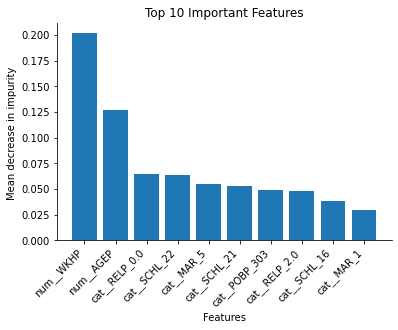

In [89]:
# 1. Get the number of trees in the forest
num_trees = len(rf_clf['classifier'].estimators_)
print("Number of trees in the forest:", num_trees)

# 2. Which are the most important features? 
important_features = rf_clf['classifier'].feature_importances_
top_feature_idxs = np.argsort(important_features)[::-1][:10]
top_10_features = [new_feature_names[i] for i in top_feature_idxs]

print("Top 10 most important features:")
for feature in top_10_features:
    print(feature)

# 3. Compute the fraction of trees that are splitting on age at their root node
age_idx= np.where(new_feature_names == 'num__AGEP')[0][0] # find AGEP feature position in new_features_list
root_node = 0

# Iterate through trees to find what feature is being split on root node 
age_root_node_count = sum([1 for tree in rf_clf['classifier'].estimators_ if tree.tree_.feature[root_node] == age_idx])
fraction_age_root_node = age_root_node_count / num_trees
print("Fraction of trees splitting on age at their root node:", fraction_age_root_node)

# 4. Plot the feature importances of the top 10 features
plt.bar(range(10), important_features[top_feature_idxs], tick_label=top_10_features)
plt.xlabel("Features")
plt.ylabel("Mean decrease in impurity ")
plt.title("Top 10 Important Features")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.show()


1. Compare top 10 important features to the results you obtained before:
- Here in our RF classifier we find that 

2. Explain the meaning of variable importance in the case of a random forest classifier.
- Feature importance for a Random Forest classifier measures the contribution of each feature to the overall predictive performance of the model. Feature importance is computed as the _mean_ reduction in Gini impurity obtained by splitting on the feature across ALL trees in the forest. Features with higher importance values indicate higher predicitive power of the target variable. This is generally a more robust measure of feature improtance.

### 3.2 Estimating AUC using K-fold CV 

Calculate the 5-fold cross-validated AUC-ROC for the random forests pipeline. Report the score for each fold as well as the average across all folds. 

**Hint 1**: sklearn.model_selection.cross_val_score is your friend. Setting the verbose option to 3 is useful. 


In [106]:
# Calculate 5-fold cross-validated AUC-ROC
cv_scores = cross_val_score(rf_clf, X_train, y_train.values.ravel(), cv=5, scoring='roc_auc', verbose=3)

# Print the score for each fold
print("AUC-ROC scores for each fold:", cv_scores)

# Calculate the average AUC-ROC across all folds
mean_auc_roc = cv_scores.mean()
print("Mean AUC-ROC across all folds:", mean_auc_roc)

[CV] END ................................ score: (test=0.868) total time=  29.6s
[CV] END ................................ score: (test=0.873) total time=  28.5s
[CV] END ................................ score: (test=0.873) total time=  30.1s
[CV] END ................................ score: (test=0.870) total time=  28.9s
[CV] END ................................ score: (test=0.874) total time=  30.6s
AUC-ROC scores for each fold: [0.86754862 0.87348419 0.87335295 0.87040372 0.87358249]
Mean AUC-ROC across all folds: 0.8716743938028738


### 3.3 Estimating AUC using nested CV 

Let's try to improve on the results of the random forest by tweaking its hyperparameters. Build a pipeline that computes the nested cv AUC-ROC. Include different values for "n_estimators", "max_samples","max_features", "max_depth" and "max_leaf_nodes" in your hyperparameter grid. Report the inner and outer fold scores for all combinations of hyperparams and interpret the results. Report the best hyperparams used in each outer fold.

What do you notice about these results? How are these results related to those from the decision tree pipeline? Is hyperparameter optimization worth the trouble?

**Hint 1**: The pipeline remains the same. You can acces the list of all the hyperparams in your pipeline with pipeline.get_params_keys(). Notice the naming convention.

**Hint 2**: GridSearchCV and cross_val_score are your friends. Specially if you run them with verbose = 3.

**Hint 3**: This gets computationally expensive quickly. Be intelligent about the hyperparam values you include in the grid.

In [110]:
## NESTED CV for Hyperparamter tuning for RF Classifier 

# Get total number of features 
tot_n_features = len(new_feature_names)

# Define hyperparameter grid
param_grid_rf = {
    'classifier__max_depth': [30],
    'classifier__max_features': [tot_n_features, 'sqrt'],
    'classifier__max_leaf_nodes': [1000],
    'classifier__n_estimators': [75, 100, 125],
    'classifier__max_samples': [0.7, 1.0],
}

# Initialize inner/outer cross-validation folds 
outer_cv_folds = 3
inner_cv_folds = 4

# Initialize lists to store results
outer_scores = []
best_params_list = []

# Perform 5-fold cross-validation
kf = KFold(n_splits=outer_cv_folds, shuffle=True, random_state=0)

# Outer cross-validation loop
for train_idx, test_idx in kf.split(X_train):
    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # Inner cross-validation for hyperparameter tuning
    inner_cv = GridSearchCV(rf_clf, param_grid_rf, cv=inner_cv_folds, scoring='roc_auc', verbose = 3)
    inner_cv.fit(X_train_fold, y_train_fold.values.ravel())

    # Best hyperparameters for each outer fold 
    best_params = inner_cv.best_params_
    best_params_list.append(best_params)

    # Note: Inner fold CV score for each combination of hyperparamaters is printed using verbose = 3 for GridSearchCV

    # Use best model to calculate outer fold score
    best_model = inner_cv.best_estimator_
    y_pred = best_model.predict_proba(X_test_fold)[:, 1]
    outer_score = roc_auc_score(y_test_fold, y_pred)
    outer_scores.append(outer_score)


Fitting 4 folds for each of 12 candidates, totalling 48 fits
[CV 1/4] END classifier__max_depth=30, classifier__max_features=287, classifier__max_leaf_nodes=1000, classifier__max_samples=0.7, classifier__n_estimators=75;, score=0.871 total time= 3.1min


In [ ]:
# 1. Report outer fold scores for best model (optimized hyperparameters)
print("Outer fold scores for RF:", outer_scores)
print('Mean outer fold score for RF: ')

# 2. Report best hyperparameters used in each outer fold
print("Best hyperparameters for each outer fold for RF:")
for i, params in enumerate(best_params_list):
    print(f"Fold {i+1}: {params}")

*your answer here*

### 3.4 Take stock of parts II and III

What do you conclude from parts II and III? If you were to choose between a decision tree and a random forest for this classification task, what would be your choice and why?

The Random Forest (RF) classifier generally outperformed the Decision Tree (DT) classifier in terms of predictive accuracy, given the higher AUC-ROC scores obtained  in 2.4 vs 3.3. 
The RFclassifier achieves better generalization performance and stability due to its ensemble nature, which combines multiple DTs thereby reducing the risk of overfitting. When analyzing feature importance, the RF 
Feature importance analysis revealed that certain features had a greater impact on the classification task in the Random Forest model compared to the Decision Tree model.
The Random Forest classifier utilized a larger number of trees, each with a varying number of features and leaf nodes, contributing to its overall complexity and robustness.
Given these observations, if I were to choose between a Decision Tree and a Random Forest for this classification task, I would prefer the Random Forest classifier. The Random Forest offers improved predictive performance, reduced overfitting, and better feature importance analysis compared to the Decision Tree. Additionally, the Random Forest's ability to handle a larger number of features and adapt to different datasets makes it a more versatile and reliable choice for classification tasks.

## Part IV: Test data, ROC curves and fairness thresholds

Note that until now, we have not used the test data for any purpose. Let's now incorporate it into our analysis and use it to find a "fair" threshold value.

### 4.1 Find the optimal hyperparameters and fit a decision tree pipeline

Use all of your training data to find the optimal hyperparameters and fit a decision tree pipeline. Report the optimal hyperparameters. 

**Note:** Recall that nested cross-validation is only providing you with an estimate of the out-of-sample performance of the model finding procedure that involves hyperparameter optimization. At training time you should carry out the entire model finding procedure, including hyperparameter optimization. 

In [108]:
# Define the hyperparameter grid
tot_n_features = len(new_feature_names)
param_grid_dt = {
    'classifier__max_depth': [15, 25, 50],
    'classifier__max_features': [tot_n_features, 'log2','sqrt'],
    'classifier__max_leaf_nodes': [500, 1000, 1500]
}

# Create the grid search object
grid_search = GridSearchCV(estimator=tree_clf, param_grid=param_grid_dt, cv=5, scoring='roc_auc', verbose=3)

# Perform grid search on the entire training data
grid_search.fit(X_train, y_train.values.ravel())

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Optimal hyperparameters:", best_params)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=500;, score=0.862 total time=   3.3s
[CV 2/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=500;, score=0.867 total time=   3.2s
[CV 3/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=500;, score=0.865 total time=   3.2s
[CV 4/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=500;, score=0.863 total time=   3.2s
[CV 5/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=500;, score=0.865 total time=   3.2s
[CV 1/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=1000;, score=0.857 total time=   4.3s
[CV 2/5] END classifier__max_depth=15, classifier__max_features=287, classifier__max_leaf_nodes=1000;, score=0.863 total time=   4.3s
[CV 3

The Optimal hyperparameters are : {'classifier__max_depth': 50, 'classifier__max_features': 287, 'classifier__max_leaf_nodes': 500}


### 4.2 Scores and the ROC curve

Use the fitted pipeline to compute score values for all instances in the test set. Show the distribution of the scores in a histogram. Additionally, compute the (FPR,TPR) combinations for all relevant threshold values and use them to plot the ROC curve in a different figure. Following the convention, include a dashed line along the diagonal. Remember to label the axes and to make the figures as polished as possible.

**Note 1**: You should NOT be using sklearn.metrics.auc or sklearn.metrics.RocCurveDisplay to calculate or display the ROC curve. Please code this part yourself.

Text(0.5, 1.0, 'Distribution of test scores for all instances in test data set')

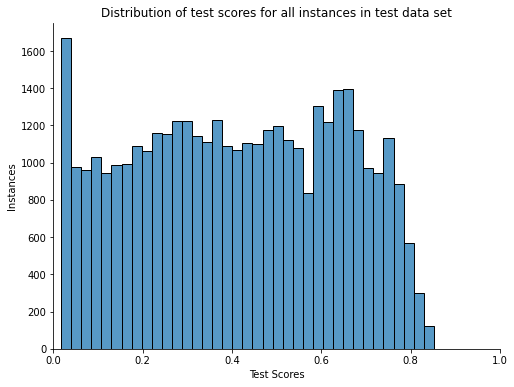

In [109]:
# Compute score values (y_hat predict) for all instances in the test set
test_scores = rf_clf.predict_proba(X_test)[:, 1] # probability target is true (1)

# Plot the distribution of scores in a histogram
plt.figure(figsize=(8, 6))
sns.histplot(test_scores)
plt.xlabel('Test Scores')
plt.xlim([0,1])
sns.despine()
plt.ylabel('Instances')
plt.title('Distribution of test scores for all instances in test data set')

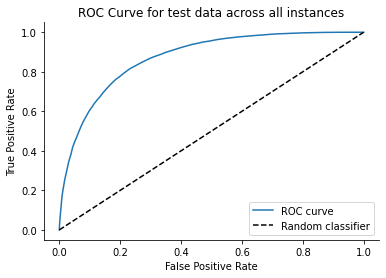

In [110]:
# Compute FPR vs TPR combinations for all threshold values 
from sklearn.metrics import confusion_matrix

# Define threshold array from 0 to 1
thresholds = np.linspace(0, 1, 100)

# Get predicted outcome based on given threshold array 
y_pred = (test_scores[:, np.newaxis] >= thresholds).astype(int)

# Calculate the tpr and fpr across all threshold values 
fpr_all = []
tpr_all = []
for idx, threshold in enumerate(thresholds):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred[:,idx]).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    fpr_all.append(fpr)
    tpr_all.append(tpr)

# Plot the ROC curve
sns.lineplot(x = fpr_all, y = tpr_all,label='ROC curve')
plt.plot([0, 1],[0, 1], color='black', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for test data across all instances')
plt.legend()
sns.despine()

### 4.3  ROC curves by racial groups

Compute and plot in the same figure the ROC curves for the following racial groups identified by the ACS:

* White (RAC1P==1) (plot in blue)
* African American (RAC1P==2) (plot in orange)
* Asian American (RAC1P==6) (plot in green)

Interpret the results.

In [111]:
def ROC_curve(rf_clf, X_test, y_test, indices):
    '''
    Function for computing TPR and FPR for x_test and y_test given set of indices specifying sub population.
    '''
    # Define sub population to analyze based on provided indices
    X_test_new = X_test.loc[indices]
    y_test_new = y_test.loc[indices]

    # calculate test scores on sub population 
    test_scores = rf_clf.predict_proba(X_test_new)[:, 1] 


    # Define threshold array from 0 to 1
    thresholds = np.linspace(0, 1, 100)

    # Get predicted outcome based on given threshold array 
    y_pred = (test_scores[:, np.newaxis] >= thresholds).astype(int)

    # Calculate the tpr and fpr across all threshold values 
    fpr_all = []
    tpr_all = []
    for idx, threshold in enumerate(thresholds):
        tn, fp, fn, tp = confusion_matrix(y_test_new, y_pred[:,idx]).ravel()
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)
        fpr_all.append(fpr)
        tpr_all.append(tpr)
    return fpr_all, tpr_all

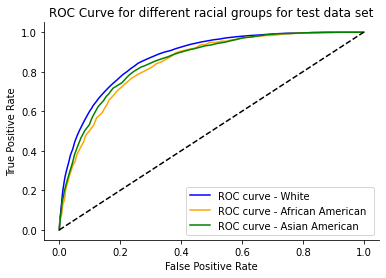

In [112]:
# Specify subset of X_test indices for given racial population 
idxs_white = X_test[X_test['RAC1P'] == 1].index.values
idxs_afr = X_test[X_test['RAC1P'] == 2].index.values
idxs_asian = X_test[X_test['RAC1P'] == 6].index.values

# Compute fpr and tpr for each racial group 
fpr_white, tpr_white = ROC_curve(rf_clf, X_test, y_test, idxs_white)
fpr_afr, tpr_afr = ROC_curve(rf_clf, X_test, y_test, idxs_afr)
fpr_asian, tpr_asian = ROC_curve(rf_clf, X_test, y_test, idxs_asian)


# Plot the ROC curves for each racial group 
sns.lineplot(x = fpr_white, y = tpr_white,color = 'blue', label='ROC curve - White')
sns.lineplot(x = fpr_afr, y = tpr_afr,color = 'orange', label='ROC curve - African American ')
sns.lineplot(x = fpr_asian, y = tpr_asian,color = 'green', label='ROC curve - Asian American')
plt.plot([0, 1],[0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for different racial groups for test data set')
plt.legend()
sns.despine()

*Results interpretation for 4.3*
- Analyzing the figure above we first notice that the AUC for the african-american curve is the smallest, followed by the asian-american curve, while the white ROC curve has the largest area. Since the AUC of the ROC curve is an indication of model performance in predicting the target, we would say that the model performs better at predicting the target  (whether an individual's income is above $50,000) better for the white population vs the african american and asian american population. To further check if the model violates equality of opportunity we could compute this metric as the white_TPR - african-american_TPR or white_TPR - asian-american_TPR.

### 4.4 Achieving error parity

Implement a thresholding strategy that satisfies error parity for all racial groups with FPR = 0.3, TPR = 0.6 and $\epsilon$ = 0.025. In plain english, find a way of setting thresholds for the members of each group in the test data that, when evaluated on the test data, delivers FPR and TPR values that differ at most from the objective values by $\epsilon$.  Plot the estimated TPRs and FPRs of the racial groups in the ROC plot. Use star markers, colored accordingly. 

**Hint**: Consider using group-specific stochastic thresholds.

In [ ]:
X_test['RAC1P'] == group

In [118]:
y_test.values.ravel().shape

(39133,)

In [117]:
test_scores.shape

(39133,)

In [ ]:
from sklearn.metrics import roc_curve # assuming we can use roc_curve now ... 

# compute test scores for all instances
test_scores = rf_clf.predict_proba(X_test)[:, 1] # probability target is true [== 1]

# Compute the ROC curve for the entire test data
fpr, tpr, thresholds = roc_curve(y_test.values.ravel(), test_scores)

# Define the desired FPR, TPR, and epsilon values
desired_fpr = 0.3
desired_tpr = 0.6
epsilon = 0.025

# Initialize lists to store the thresholds for each racial group
thresholds_by_group = []

# Iterate over each racial group
racial_groups = [1,2,6]
for group in racial_groups:
    # Compute the indices of instances belonging to the current group
    group_indices = np.where(X_test['RAC1P'] == group)[0]
    
    # Compute the group-specific FPR and TPR
    group_fpr = fpr[group_indices]
    group_tpr = tpr[group_indices]
    
    # Find the threshold that satisfies error parity
    group_threshold = thresholds[np.argmin(np.abs(group_fpr - desired_fpr))]
    
    # Append the threshold to the list
    thresholds_by_group.append(group_threshold)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='Overall ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Plot the estimated TPRs and FPRs of the racial groups
colors = ['red', 'green', 'orange', 'purple']  # Assuming racial groups are represented by different colors
markers = ['*', 's', 'o', 'D']  # Marker styles for different racial groups

for i, group in enumerate(racial_groups):
    # Compute the indices of instances belonging to the current group
    group_indices = np.where(X_test['race'] == group)[0]
    
    # Plot the estimated TPRs and FPRs
    plt.scatter(fpr[group_indices], tpr[group_indices], color=colors[i], marker=markers[i], label=f'{group} group')

plt.legend()
plt.grid(True)
plt.show()


### 4.5 Improving the results [extra-credit]

Can you improve the results from 4.4? That is, can you tweak your algorithm to deliver a higher TPR and lower FPR while still satisfying error parity with epsilon = 0.025? What is the best result that you are able to achieve? Is there a hard limit on how much you can improve?

In [ ]:
# your code here

*your observations here*

### 4.6 Conclusion

What can you say about welfare and error parity? Some things to consider:

* In this income prediction task, is enforcing error parity costly?
* Would you expect this results to generalize to other predictions problems?
* Is the group definition relevant?
* Who benefits from enforcing error parity? Who doesn't?

*your observations here*